In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"../data/db/bluestock_mf.db"

cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('fund_master',), ('nav_history',), ('aum_by_fund_house',), ('monthly_sip_inflows',), ('category_inflows',), ('industry_folio_count',), ('scheme_performance',), ('investor_transactions',), ('portfolio_holdings',), ('benchmark_indices',)]


In [4]:
from pathlib import Path

db_path = Path("../bluestock_mf.db")

print("Notebook location:", Path.cwd())
print("Database exists:", db_path.exists())
print("Database path:", db_path.resolve())
print("Database size (bytes):", db_path.stat().st_size if db_path.exists() else "Not found")

Notebook location: c:\Users\mrnan\OneDrive\Desktop\Bluestock\MutualFundAnalytics\notebooks
Database exists: True
Database path: C:\Users\mrnan\OneDrive\Desktop\Bluestock\MutualFundAnalytics\bluestock_mf.db
Database size (bytes): 5177344


In [5]:
df = pd.read_sql("SELECT * FROM fund_master", conn)

df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

df.info()

Number of Rows : 40
Number of Columns : 15
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), st

In [6]:
df.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [7]:
df.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [8]:
print("Unique Fund Houses:", df["fund_house"].nunique())

Unique Fund Houses: 10


In [9]:
print(df["category"].value_counts())

category
Equity    34
Debt       6
Name: count, dtype: int64


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

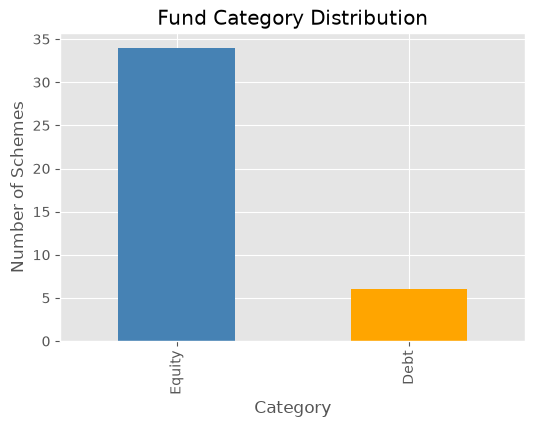

In [22]:
#2. Fund Category Distribution
plt.figure(figsize=(6,4))

df["category"].value_counts().plot(
    kind="bar",
    color=["steelblue","orange"]
)

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Schemes")

plt.show()

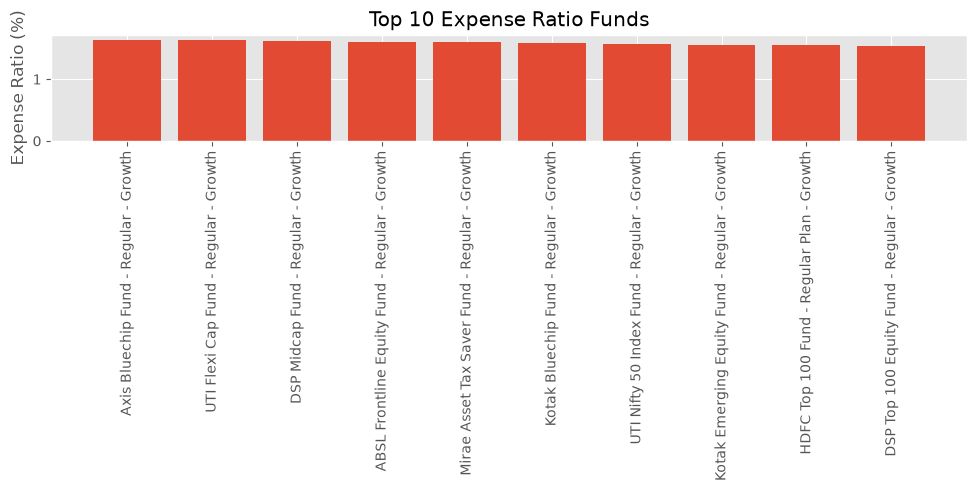

In [21]:
#3. Top 10 Expense Ratio Funds
top_expense = df.sort_values(
    by="expense_ratio_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_expense["scheme_name"],
    top_expense["expense_ratio_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Expense Ratio Funds")

plt.ylabel("Expense Ratio (%)")

plt.tight_layout()

plt.show()

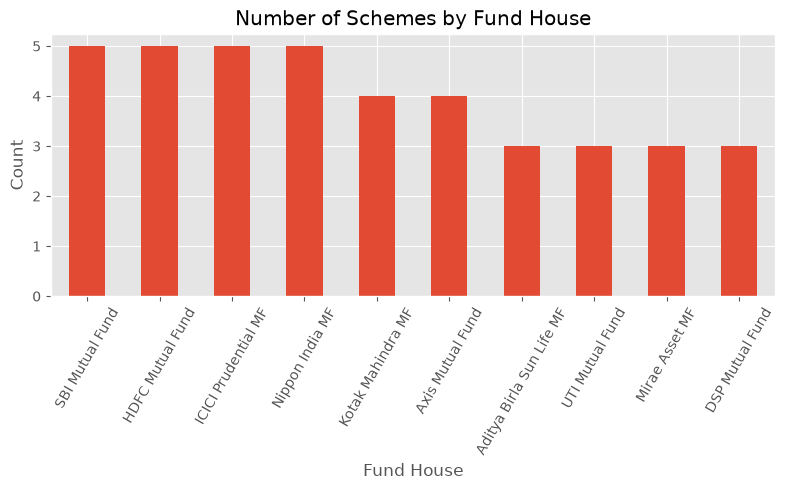

In [20]:
#4.Fund Houses Distribution 
plt.figure(figsize=(8,5))

df["fund_house"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Schemes by Fund House")

plt.xlabel("Fund House")

plt.ylabel("Count")

plt.xticks(rotation=60)

plt.tight_layout()

plt.show()

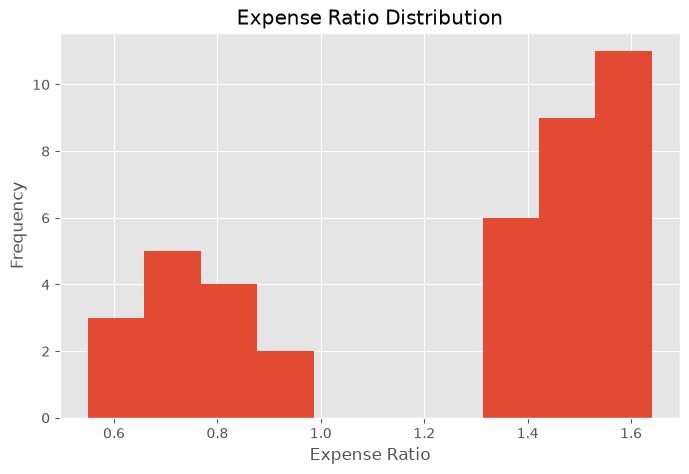

In [19]:
#5. Expense Ratio Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio")

plt.ylabel("Frequency")

plt.show()

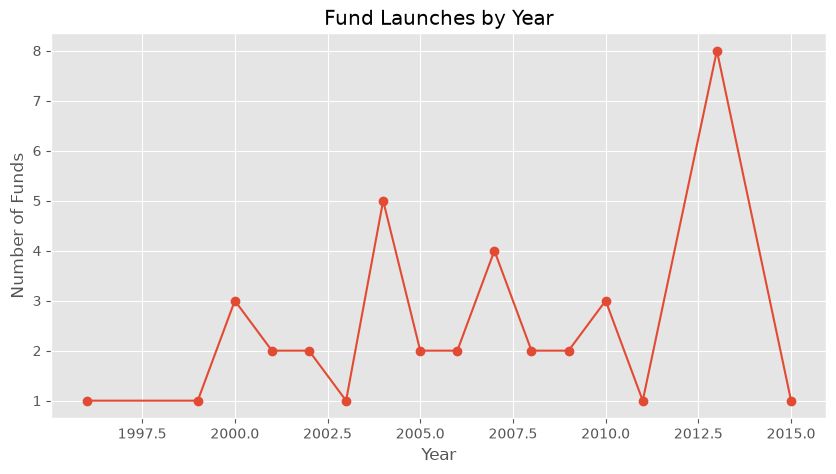

In [ ]:
#6. Launch Year Distribution
df["launch_date"] = pd.to_datetime(df["launch_date"])

launch_year = df["launch_date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))

launch_year.plot(kind="line", marker="o")

plt.title("Fund Launches by Year")

plt.xlabel("Year")

plt.ylabel("Number of Funds")

plt.grid(True)

plt.show()

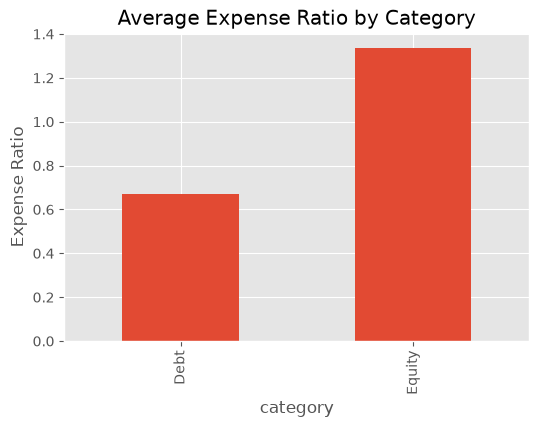

In [ ]:
#7. Average Expense Ratio by Category
avg_expense = df.groupby("category")["expense_ratio_pct"].mean()

plt.figure(figsize=(6,4))

avg_expense.plot(kind="bar")

plt.title("Average Expense Ratio by Category")

plt.ylabel("Expense Ratio")

plt.show()